# GridSearchCV models

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from src.data import load_raw_tables, prepare_delivery_events, build_master_df, add_engineering_features
from src.preprocessing_data import split_data, scale_data, prepare_training_data
from src.data_load import apply_pca
from sklearn.svm import SVC


In [2]:
base_path = r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1"
tables = load_raw_tables(base_path)
delivery_events = prepare_delivery_events(tables["delivery_events"])
df = build_master_df(
    delivery_events,
    tables["trips"],
    tables["loads"],
    tables["drivers"],
    tables["trucks"],
    tables["routes"],
    tables["customers"]
)
df = add_engineering_features(df)

In [3]:
# Removing rows with missing values in 'CustomerID' and 'Description' columns
df = df.dropna(subset=['is_home_terminal', 'years_experience','efficiency_ratio','truck_age_at_event'])

In [4]:
# Final Column Selection (The Optimized List)
final_columns = [
    'on_time_flag', 
    'location_state',
    'facility_congestion_score', 
    'facility_detention_avg',
    'hour_of_day', 
    'day_of_week', 
    'event_type',
    'booking_type',
    'weight_lbs', 
    'pieces',
    'revenue',
    'load_type',
    'years_experience', 
    'truck_age_at_event',
    'average_mpg', 
    'idle_time_hours',
    'distance_deviation',
    'is_home_terminal', 
    'detention_risk_index', 
    'efficiency_ratio', 
    'revenue_density',
    'is_winter'
]

In [5]:
# Separate Features and Target
categorical_cols = ['day_of_week', 'event_type', 'booking_type', 'load_type','location_state']
numeric_cols = [
    'facility_congestion_score', 'facility_detention_avg', 'hour_of_day', 
    'weight_lbs', 'pieces', 'revenue', 'years_experience', 
    'truck_age_at_event', 'average_mpg', 'idle_time_hours', 'distance_deviation',
    'is_home_terminal', 'detention_risk_index', 'efficiency_ratio', 'revenue_density','is_winter'
]
target = 'on_time_flag'

In [6]:
# Create df for model training
df_model = df[categorical_cols + numeric_cols + [target]].copy()

In [7]:
# ONE-HOT ENCODING to convertstext categories into 0/1 columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

In [8]:
X_train_scaled, X_test_scaled, y_train, y_test, imputer, scaler = prepare_training_data(
    df_encoded, target
)

In [9]:
X_train_pca, X_test_pca, pca = apply_pca(
    X_train_scaled,
    X_test_scaled,
    n_components=21   # or 0.95 if you want automatic selection
)

## Logistic Regression + GridSearchCV

In [10]:
# train model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
# Set parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}


In [11]:
# GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",   # good for multiclass or imbalanced classes
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [12]:
# Best model
best_log_reg = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.6073295826536416


In [13]:
# Predictions
y_pred = best_log_reg.predict(X_test_pca)

In [14]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression + GridSearchCV Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression + GridSearchCV Results
Accuracy : 0.5829
Precision: 0.5962
Recall   : 0.7766
F1 Score : 0.6746


In [15]:
# 12. Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.55      0.34      0.42     14556
        True       0.60      0.78      0.67     18269

    accuracy                           0.58     32825
   macro avg       0.57      0.56      0.55     32825
weighted avg       0.57      0.58      0.56     32825




Confusion Matrix:


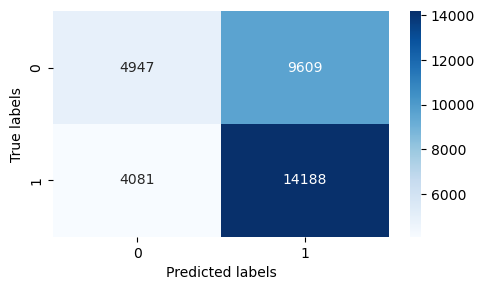

In [16]:
from IPython.display import display, HTML
display(HTML("<div style='height:50px;'></div>"))
HTML("<br><br><br>")

print("\nConfusion Matrix:")
cm=confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",          # <-- THIS is the key line
    cmap="Blues"
)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()

plt.show()

In [35]:
# 14. Save results in a table
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression + GridSearchCV",
        "Best Params": str(grid_search.best_params_),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
])

results_df

,Model,Best Params,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression + GridSearchCV,{'C': 0.01},0.582727,0.59593,0.777328,0.674648


## SGDClassifier (Stochastic Gradient Descent) + GridSearchCV

In [19]:
from sklearn.linear_model import SGDClassifier

# Define model
sgd_model = SGDClassifier(random_state=42)

#  Parameter grid
param_grid = {
    "loss": ["hinge", "log_loss"],
    "alpha": [0.0001, 0.001, 0.01],
    "max_iter": [1000, 2000]
}

#  Grid search
grid_search = GridSearchCV(
    estimator=sgd_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train)


,estimator,SGDClassifier(random_state=42)
,param_grid,"{'alpha': [0.0001, 0.001, ...], 'loss': ['hinge', 'log_loss'], 'max_iter': [1000, 2000]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [29]:
# Best model
best_sgd = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)






Best Parameters: {'C': 0.01}
Best CV Score: 0.5790155293037652


In [30]:
# Predict
y_pred = best_sgd.predict(X_test_pca)

# 11. Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nSGDClassifier + PCA + GridSearchCV Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


SGDClassifier + PCA + GridSearchCV Results
Accuracy : 0.5827
Precision: 0.5959
Recall   : 0.7773
F1 Score : 0.6746


In [21]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

       False       0.54      0.32      0.40     14556
        True       0.59      0.79      0.68     18269

    accuracy                           0.58     32825
   macro avg       0.57      0.55      0.54     32825
weighted avg       0.57      0.58      0.55     32825




Confusion Matrix:


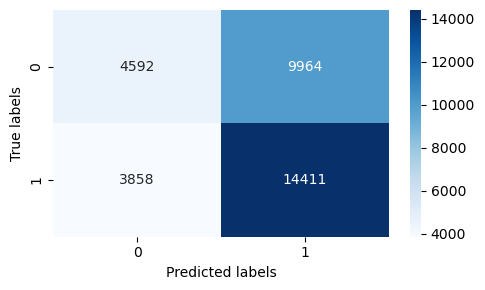

In [22]:
from IPython.display import display, HTML
display(HTML("<div style='height:50px;'></div>"))
HTML("<br><br><br>")

print("\nConfusion Matrix:")
cm=confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",          # <-- THIS is the key line
    cmap="Blues"
)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()

plt.show()

In [31]:
sgd_results = pd.DataFrame([
    {
        "Model": "SGDClassifier + GridSearchCV",
        "Best Params": str(grid_search.best_params_),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
])

sgd_results

,Model,Best Params,Accuracy,Precision,Recall,F1 Score
0,SGDClassifier + GridSearchCV,{'C': 0.01},0.582727,0.59593,0.777328,0.674648


## LinearSVC + GridSearchCV

In [24]:
from sklearn.svm import LinearSVC

# Define model
linear_svc = LinearSVC(random_state=42, max_iter=5000)

# Parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

# Grid search
grid_search = GridSearchCV(
    estimator=linear_svc,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_pca, y_train)


,estimator,LinearSVC(max...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [32]:
# Best model
best_linear_svc = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)





Best Parameters: {'C': 0.01}
Best CV Score: 0.5790155293037652


In [33]:
# Predict
y_pred = best_linear_svc.predict(X_test_pca)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nLinearSVC + PCA + GridSearchCV Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")



LinearSVC + PCA + GridSearchCV Results
Accuracy : 0.5827
Precision: 0.5959
Recall   : 0.7773
F1 Score : 0.6746


In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.55      0.34      0.42     14556
        True       0.60      0.78      0.67     18269

    accuracy                           0.58     32825
   macro avg       0.57      0.56      0.55     32825
weighted avg       0.57      0.58      0.56     32825




Confusion Matrix:


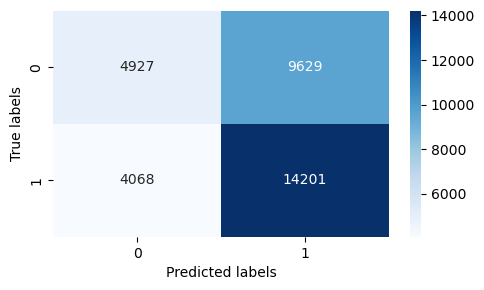

In [27]:
from IPython.display import display, HTML
display(HTML("<div style='height:50px;'></div>"))
HTML("<br><br><br>")

print("\nConfusion Matrix:")
cm=confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",          # <-- THIS is the key line
    cmap="Blues"
)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()

plt.show()

In [38]:
linear_svc_results = pd.DataFrame([
    {
        "Model": "LinearSVC + GridSearchCV",
        "Best Params": str(grid_search.best_params_),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
])

linear_svc_results

,Model,Best Params,Accuracy,Precision,Recall,F1 Score
0,LinearSVC + GridSearchCV,{'C': 0.01},0.582727,0.59593,0.777328,0.674648
